<a href="https://colab.research.google.com/github/AndreiAf02/Data-Balancing-in-ML-DNN/blob/main/CIFAR10_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##CIFAR-10 Dataset - ML Classification with Random Under/Oversampling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from time import perf_counter



from sklearn.preprocessing import StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
# !pip install pytorch-tabnet

# from pytorch_tabnet.tab_model import TabNetClassifier
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.datasets import make_classification
import random

from imblearn.datasets import make_imbalance



from keras.datasets import mnist, fashion_mnist, cifar10
# import tensorflow_datasets as tfds




## Downloading the MNIST Data:

In [ ]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

# (train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [ ]:
np.unique(train_labels)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

[4]


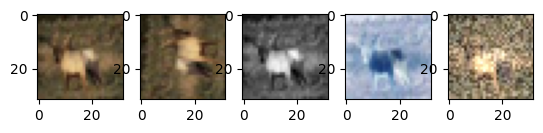

In [ ]:
i = 3

print(train_labels[i])

figure_for_plotting = train_images[i] #.transpose((1, 0, 2))
plt.subplot(1, 5, 1)
plt.imshow(figure_for_plotting)

plt.subplot(1, 5, 2)
plt.imshow(figure_for_plotting.transpose((1, 0, 2)))

# np.clip(noisy_figure, 0, 255)
gs_figure_for_plotting = np.mean(train_images[i],axis=2)
plt.subplot(1, 5, 3)
plt.imshow(gs_figure_for_plotting, cmap='gray')


plt.subplot(1, 5, 4)
plt.imshow(-figure_for_plotting)


noisy_figure = figure_for_plotting + np.random.randint(0,100,size=(figure_for_plotting.shape[0], figure_for_plotting.shape[1], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)

plt.subplot(1, 5, 5)
plt.imshow(noisy_figure)

## Creating the Imbalanced training set using Data Augmentation (Deer vs Dogs):

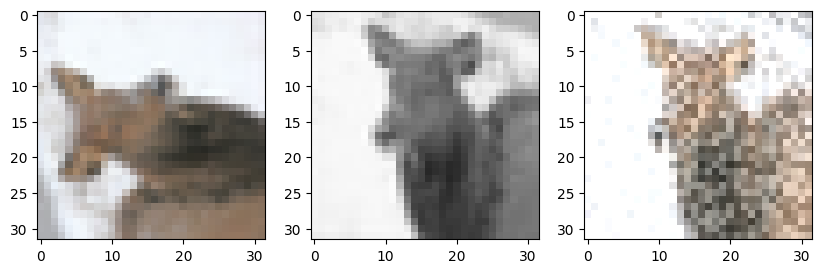

In [ ]:
maj_label=4
min_label=5

max_noise = 100

# train_binary_maj = train_images[np.where(np.isin(train_labels,[maj_label,min_label]))]
maj_index = np.where(train_labels == maj_label)
train_binary_label1 = train_images[maj_index[0]]

# train_binary_maj = train_binary_label1

orig_maj_len = len(train_binary_label1)

# train_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = train_binary_label1.transpose((0, 2, 1, 3))
# train_binary_maj = np.append(train_binary_maj, maj_transpose, axis=0)
train_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - train_binary_label1
# train_binary_maj = np.append(train_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = train_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
train_binary_maj = np.append(train_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = train_binary_label1 + np.random.randint(0,max_noise,size=(train_binary_label1.shape[0], train_binary_label1.shape[1], train_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
train_binary_maj = np.append(train_binary_maj, noisy_figure, axis=0)


# print(train_binary_maj)


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 3, 1)
plt.imshow(train_binary_maj[orig_maj_len-1])

plt.subplot(1, 3, 2)
plt.imshow(train_binary_maj[2*orig_maj_len-1])

# plt.subplot(1, 5, 3)
# plt.imshow(train_binary_maj[3*orig_maj_len-1])

plt.subplot(1, 3, 3)
plt.imshow(train_binary_maj[3*orig_maj_len-1])

# plt.subplot(1, 4, 4)
# plt.imshow(train_binary_maj[4*orig_maj_len-1])

np.random.seed(333)
np.random.shuffle(train_binary_maj)



Text(0.5, 1.0, 'Original Figure')

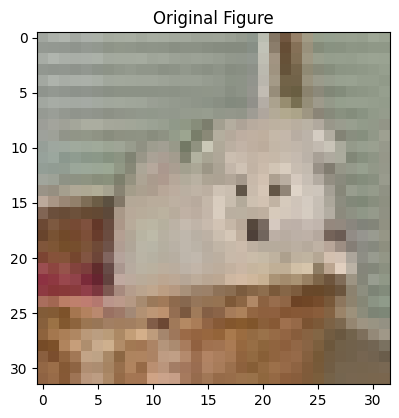

In [ ]:
min_index = np.where(train_labels == min_label)
train_binary_label2 = train_images[min_index[0]]


train_binary_min = train_binary_label2

# noisy_figure = train_binary_label2 + np.random.randint(0,max_noise,size=(train_binary_label2.shape[0], train_binary_label2.shape[1], train_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# train_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(train_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(train_binary_min[-1])
# plt.title('Noisy Figure')

In [ ]:
print(train_binary_maj.shape)
print(train_binary_min.shape)


train_maj_label = [maj_label]*len(train_binary_maj)
train_min_label = [min_label]*len(train_binary_min)

train_maj_label_binary = [0]*len(train_binary_maj)
train_min_label_binary = [1]*len(train_binary_min)

train_binary_total = np.append(train_binary_maj, train_binary_min, axis=0)
train_label_total = train_maj_label + train_min_label
train_label_total_binary = train_maj_label_binary + train_min_label_binary

pd.Series(train_label_total_binary).value_counts()


(15000, 32, 32, 3)
(5000, 32, 32, 3)


,count
0,15000
1,5000


In [ ]:
train_binary_scaled = train_binary_total.astype('float32')/255.
train_binary_flattened = train_binary_scaled.reshape(train_binary_scaled.shape[0], -1)
train_binary_flattened = pd.DataFrame(train_binary_flattened)
train_binary_flattened['Y'] = train_label_total_binary

train_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
19995,0.760784,0.768627,0.784314,0.705882,0.705882,0.721569,0.698039,0.698039,0.713726,0.776471,...,0.745098,0.694118,0.662745,0.752941,0.701961,0.666667,0.756863,0.705882,0.674510,1
19996,0.733333,0.725490,0.717647,0.768627,0.784314,0.784314,0.764706,0.772549,0.772549,0.776471,...,0.317647,0.309804,0.317647,0.298039,0.290196,0.301961,0.392157,0.384314,0.396078,1
19997,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.003922,0.003922,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1
19998,0.431373,0.450980,0.427451,0.352941,0.478431,0.407843,0.321569,0.458824,0.372549,0.345098,...,0.184314,0.360784,0.286275,0.152941,0.317647,0.254902,0.262745,0.360784,0.317647,1
19999,0.631373,0.650980,0.623529,0.674510,0.694118,0.666667,0.690196,0.709804,0.682353,0.643137,...,0.470588,0.400000,0.309804,0.474510,0.400000,0.305882,0.478431,0.400000,0.305882,1


## Creating the Imbalanced testing set using Data Augmentation:

3000


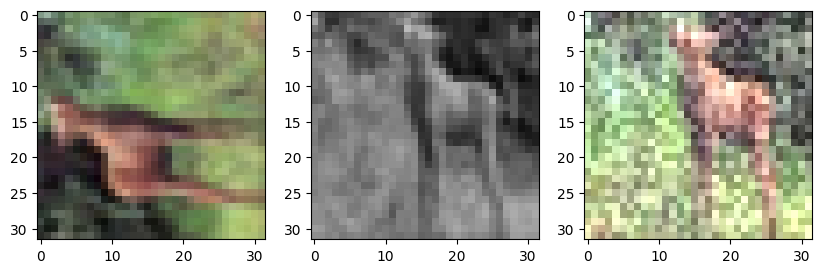

In [ ]:
maj_index = np.where(test_labels == maj_label)
test_binary_label1 = test_images[maj_index[0]]

# test_binary_maj = test_binary_label1

orig_maj_len = len(test_binary_label1)

# test_binary_maj.shape

# Incorporating the transposed image:
maj_transpose = test_binary_label1.transpose((0, 2, 1, 3))
# test_binary_maj = np.append(test_binary_maj, maj_transpose, axis=0)
test_binary_maj = maj_transpose

# ## Incorporating the negative image:
# maj_negative = 255 - test_binary_label1
# test_binary_maj = np.append(test_binary_maj, maj_negative, axis=0)

## Incoporating the grayscale image:
gs_fig = test_binary_label1.mean(axis=3).astype(int)
gs_fig = np.concatenate(([gs_fig], [gs_fig], [gs_fig]), axis=0)
gs_fig = gs_fig.transpose((1, 2, 3, 0))
gs_fig.shape
test_binary_maj = np.append(test_binary_maj, gs_fig, axis=0)

## Incorporating the noisy image:
noisy_figure = test_binary_label1 + np.random.randint(0,max_noise,size=(test_binary_label1.shape[0], test_binary_label1.shape[1], test_binary_label1.shape[2], 1))
noisy_figure = np.clip(noisy_figure, 0, 255)
test_binary_maj = np.append(test_binary_maj, noisy_figure, axis=0)

print(len(test_binary_maj))


## Plotting the example figures:
plt.figure(figsize=(10, 30))
plt.subplot(1, 3, 1)
plt.imshow(test_binary_maj[orig_maj_len-1])

plt.subplot(1, 3, 2)
plt.imshow(test_binary_maj[2*orig_maj_len-1])

# plt.subplot(1, 5, 3)
# plt.imshow(test_binary_maj[3*orig_maj_len-1])
# plt.title('Negative')

plt.subplot(1, 3, 3)
plt.imshow(test_binary_maj[3*orig_maj_len-1])

# plt.subplot(1, 4, 4)
# plt.imshow(test_binary_maj[4])


np.random.seed(333)
np.random.shuffle(test_binary_maj)



Text(0.5, 1.0, 'Original Figure')

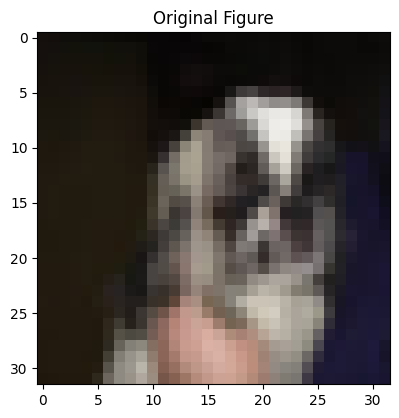

In [ ]:
min_index = np.where(test_labels == min_label)
test_binary_label2 = test_images[min_index[0]]

test_binary_min = test_binary_label2

# noisy_figure = test_binary_label2 + np.random.randint(0,max_noise,size=(test_binary_label2.shape[0], test_binary_label2.shape[1], test_binary_label2.shape[2], 1))
# noisy_figure = np.clip(noisy_figure, 0, 255)
# test_binary_min = noisy_figure


plt.figure(figsize=(10, 12))
plt.subplot(1, 2, 1)
plt.imshow(test_binary_label2[-1])
plt.title('Original Figure')

# plt.subplot(1, 2, 2)
# plt.imshow(test_binary_min[-1])
# plt.title('Noisy Figure')

In [ ]:
print(test_binary_maj.shape)
print(test_binary_min.shape)


test_maj_label = [maj_label]*len(test_binary_maj)
test_min_label = [min_label]*len(test_binary_min)

test_maj_label_binary = [0]*len(test_binary_maj)
test_min_label_binary = [1]*len(test_binary_min)

test_binary_total = np.append(test_binary_maj, test_binary_min, axis=0)
test_label_total = test_maj_label + test_min_label
test_label_total_binary = test_maj_label_binary + test_min_label_binary

pd.Series(test_label_total_binary).value_counts()


(3000, 32, 32, 3)
(1000, 32, 32, 3)


,count
0,3000
1,1000


In [ ]:
test_binary_scaled = test_binary_total.astype('float32')/255.
test_binary_flattened = test_binary_scaled.reshape(test_binary_scaled.shape[0], -1)
test_binary_flattened = pd.DataFrame(test_binary_flattened)
test_binary_flattened['Y'] = test_label_total_binary

test_binary_flattened.tail()

,0,1,2,3,4,5,6,7,8,9,...,3063,3064,3065,3066,3067,3068,3069,3070,3071,Y
3995,0.545098,0.521569,0.262745,0.603922,0.576471,0.329412,0.776471,0.784314,0.647059,0.768627,...,0.709804,0.749020,0.600000,0.670588,0.694118,0.545098,0.623529,0.639216,0.498039,1
3996,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,...,0.388235,0.219608,0.188235,0.364706,0.188235,0.152941,0.341176,0.164706,0.133333,1
3997,0.325490,0.372549,0.356863,0.262745,0.349020,0.415686,0.364706,0.407843,0.419608,0.576471,...,0.345098,0.384314,0.384314,0.286275,0.337255,0.345098,0.298039,0.368627,0.376471,1
3998,0.372549,0.384314,0.360784,0.364706,0.360784,0.352941,0.376471,0.349020,0.360784,0.360784,...,0.227451,0.219608,0.243137,0.207843,0.200000,0.223529,0.211765,0.203922,0.227451,1
3999,0.078431,0.058824,0.047059,0.074510,0.054902,0.043137,0.058824,0.054902,0.043137,0.058824,...,0.094118,0.090196,0.196078,0.101961,0.090196,0.207843,0.098039,0.078431,0.184314,1


In [ ]:
train_binary_flattened['test'] = 0
test_binary_flattened['test'] = 1
data2 = pd.concat([train_binary_flattened, test_binary_flattened])

data2.tail()

,0,1,2,3,4,5,6,7,8,9,...,3064,3065,3066,3067,3068,3069,3070,3071,Y,test
3995,0.545098,0.521569,0.262745,0.603922,0.576471,0.329412,0.776471,0.784314,0.647059,0.768627,...,0.749020,0.600000,0.670588,0.694118,0.545098,0.623529,0.639216,0.498039,1,1
3996,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,0.027451,0.023529,0.043137,...,0.219608,0.188235,0.364706,0.188235,0.152941,0.341176,0.164706,0.133333,1,1
3997,0.325490,0.372549,0.356863,0.262745,0.349020,0.415686,0.364706,0.407843,0.419608,0.576471,...,0.384314,0.384314,0.286275,0.337255,0.345098,0.298039,0.368627,0.376471,1,1
3998,0.372549,0.384314,0.360784,0.364706,0.360784,0.352941,0.376471,0.349020,0.360784,0.360784,...,0.219608,0.243137,0.207843,0.200000,0.223529,0.211765,0.203922,0.227451,1,1
3999,0.078431,0.058824,0.047059,0.074510,0.054902,0.043137,0.058824,0.054902,0.043137,0.058824,...,0.090196,0.196078,0.101961,0.090196,0.207843,0.098039,0.078431,0.184314,1,1


In [ ]:
data2['Y'].value_counts()

,count
Y,
0,18000
1,6000


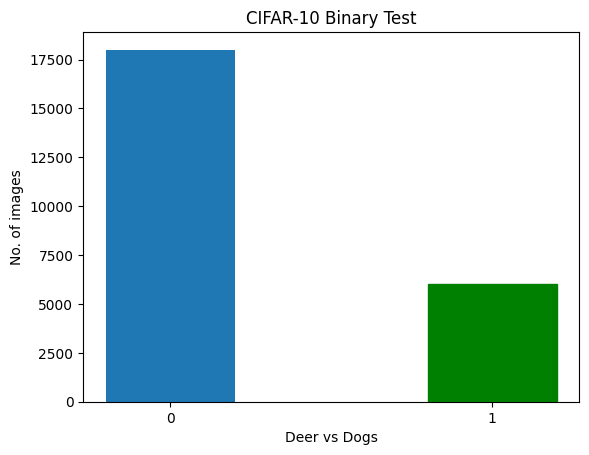

In [ ]:
barlist = plt.bar([str(0),str(1)], data2['Y'].value_counts(), width = 0.4)
barlist[1].set_color('g')

plt.xlabel("Deer vs Dogs")
plt.ylabel("No. of images")
plt.title("CIFAR-10 Binary Test")
plt.show()

# Full Dataset:

## DNN Classification Algorithm:

In [ ]:
def create_dnn_model(input_shape):
  model = models.Sequential([layers.Dense(64, activation='relu', input_dim=input_shape),
        layers.Dense(32, activation='relu'),
        layers.Dense(1, activation='sigmoid')  # For binary classification (yes/no)
    ])

  model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])

  return model



def train_and_evaluate_ml(model, X_train, X_test, y_train, y_test, domain):

    # time_start = perf_counter()

    # Training and validation
    model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

    # Predict probabilities and calculate AUC
    y_pred_prob = model.predict(X_test).ravel()
    auc = roc_auc_score(y_test, y_pred_prob)
    print(f"AUC-ROC: {auc}")

    # Compute ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

    # Convert probabilities to binary predictions for confusion matrix
    y_pred_class = (y_pred_prob >= 0.5).astype(int)

    # Compute and print classification report
    class_report = classification_report(y_test, y_pred_class)
    print("Classification Report:")
    print(class_report)

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred_class)

    fpr = conf_matrix[0][1]/(conf_matrix[0][0]+conf_matrix[0][1])
    tnr = 1-fpr

    fnr = conf_matrix[1][0]/(conf_matrix[1][0] + conf_matrix[1][1])
    tpr = 1 - fnr
    print('FPR', fpr, 'TPR:', tpr, 'FNR:', fnr, 'TNR:', tnr)

    # conf_disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)

    # ## To deactivate after!!! ----------------------------------------
    # ##### Plot ROC curve and Confusion Matrix side by side
    # fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # # ROC Curve
    # ax1.plot(fpr, tpr, color='blue', label=f'AUC-ROC = {auc:.2f}')
    # ax1.plot([0, 1], [0, 1], color='gray', linestyle='--')
    # ax1.set_xlabel('False Positive Rate')
    # ax1.set_ylabel('True Positive Rate')
    # ax1.set_title('Receiver Operating Characteristic (ROC) Curve')
    # ax1.legend(loc='lower right')
    # ax1.grid()

    # # Confusion Matrix
    # conf_disp.plot(ax=ax2, cmap='Blues')
    # ax2.set_title('Confusion Matrix')
    # plt.tight_layout()
    # plt.show()
    ## To deactivate after!!! ----------------------------------------

    # Calculate precision and recall for different thresholds
    precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

    # Find the threshold where precision and recall are balanced
    f1_scores = 2 * (precision * recall) / (precision + recall)
    best_threshold = thresholds[f1_scores.argmax()]

    print(f"Best threshold based on F1-score: {best_threshold}")

    return fpr, tnr, fnr, tpr


In [ ]:
train_data = data2[data2['test']==0]
train_data = train_data.iloc[:, :-1]
X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

test_data = data2[data2['test']==1]
test_data = test_data.iloc[:, :-1]
X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]

In [ ]:
y_train.value_counts()

,count
Y,
0,15000
1,5000


In [ ]:
y_test.value_counts()

,count
Y,
0,3000
1,1000


In [ ]:
print('X_train:',np.shape(X_train))
print('y_train:',np.shape(y_train))
print('X_test:',np.shape(X_test))
print('y_test:',np.shape(y_test))

X_train: (20000, 3072)
y_train: (20000,)
X_test: (4000, 3072)
y_test: (4000,)


In [ ]:
## Establishing the Under/Oversampling values and imbalance ratio:

undersample_size = min(train_data.iloc[:,-1].value_counts())
oversample_size = max(train_data.iloc[:,-1].value_counts())


data_majority = train_data[train_data.iloc[:,-1]==0]
data_minority = train_data[train_data.iloc[:,-1]==1]

print(undersample_size)
print(oversample_size)

5000
15000


## Imbalanced (Original) data:

In [ ]:
times = 50

FPR = []
TPR = []
FNR = []
TNR = []


for i in range(times):
    model_source = create_dnn_model(X_train.shape[1])
    result_imbalanced = train_and_evaluate_ml(model_source, X_train, X_test, y_train, y_test, "Source")
    # result_TL_imbalanced = Transductive_TL(model_source, X_T_full, y_T_full, "Target")

    FPR.append(result_imbalanced[0])
    TNR.append(result_imbalanced[1])
    FNR.append(result_imbalanced[2])
    TPR.append(result_imbalanced[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']
# print(ParamFit)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.6004 - loss: 0.2583 - val_AUC: 0.0000e+00 - val_loss: 2.8269
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7085 - loss: 0.2154 - val_AUC: 0.0000e+00 - val_loss: 3.1044
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7296 - loss: 0.2045 - val_AUC: 0.0000e+00 - val_loss: 2.1908
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.7667 - loss: 0.1897 - val_AUC: 0.0000e+00 - val_loss: 1.9459
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7947 - loss: 0.1829 - val_AUC: 0.0000e+00 - val_loss: 1.8896
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8002 - loss: 0.1886 - val_AUC: 0.0000e+00 - val_loss: 1.6523
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.8246 - loss: 0.1796 - val_AUC: 0.0000e+00 - val_loss: 1.3967
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - AUC: 0.8289 - loss: 0.1783 - val_AUC: 0.0000e+00 - val_loss: 2.0471
Epoch 9/10
500/500 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.6289 - loss: 0.2322 - val_AUC: 0.0000e+00 - val_loss: 2.2918
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7028 - loss: 0.2129 - val_AUC: 0.0000e+00 - val_loss: 1.9050
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7468 - loss: 0.2061 - val_AUC: 0.0000e+00 - val_loss: 2.1601
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.7749 - loss: 0.1907 - val_AUC: 0.0000e+00 - val_loss: 1.9442
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7895 - loss: 0.1839 - val_AUC: 0.0000e+00 - val_loss: 1.4256
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8026 - loss: 0.1751 - val_AUC: 0.0000e+00 - val_loss: 2.0898
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8120 - loss: 0.1683 - val_AUC: 0.0000e+00 - val_loss: 1.6238
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8286 - loss: 0.1745 - val_AUC: 0.0000e+00 - val_loss: 2.1012
Epoch 9/10
500/500 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - AUC: 0.6300 - loss: 0.2429 - val_AUC: 0.0000e+00 - val_loss: 2.9337
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.7163 - loss: 0.2061 - val_AUC: 0.0000e+00 - val_loss: 2.0887
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7656 - loss: 0.1994 - val_AUC: 0.0000e+00 - val_loss: 2.2655
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7912 - loss: 0.1892 - val_AUC: 0.0000e+00 - val_loss: 2.2289
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.7934 - loss: 0.1980 - val_AUC: 0.0000e+00 - val_loss: 1.9851
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.7881 - loss: 0.1833 - val_AUC: 0.0000e+00 - val_loss: 2.7751
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8208 - loss: 0.1782 - val_AUC: 0.0000e+00 - val_loss: 2.0947
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.8068 - loss: 0.1751 - val_AUC: 0.0000e+00 - val_loss: 1.7244
Epoch 9/10
500/500 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.5880 - loss: 0.2715 - val_AUC: 0.0000e+00 - val_loss: 2.6512
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - AUC: 0.6779 - loss: 0.2229 - val_AUC: 0.0000e+00 - val_loss: 2.3549
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7230 - loss: 0.2088 - val_AUC: 0.0000e+00 - val_loss: 1.8716
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7597 - loss: 0.1954 - val_AUC: 0.0000e+00 - val_loss: 2.4735
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8122 - loss: 0.1844 - val_AUC: 0.0000e+00 - val_loss: 2.1195
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.7969 - loss: 0.1830 - val_AUC: 0.0000e+00 - val_loss: 2.3392
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8121 - loss: 0.1830 - val_AUC: 0.0000e+00 - val_loss: 2.8239
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8068 - loss: 0.1796 - val_AUC: 0.0000e+00 - val_loss: 1.8725
Epoch 9/10
500/500 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.6203 - loss: 0.2485 - val_AUC: 0.0000e+00 - val_loss: 2.7328
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - AUC: 0.7099 - loss: 0.2127 - val_AUC: 0.0000e+00 - val_loss: 2.5706
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.7581 - loss: 0.2085 - val_AUC: 0.0000e+00 - val_loss: 3.3410
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7793 - loss: 0.1913 - val_AUC: 0.0000e+00 - val_loss: 1.6795
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.7987 - loss: 0.1882 - val_AUC: 0.0000e+00 - val_loss: 1.6905
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8071 - loss: 0.1771 - val_AUC: 0.0000e+00 - val_loss: 2.1479
Epoch 7/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - AUC: 0.8240 - loss: 0.1758 - val_AUC: 0.0000e+00 - val_loss: 1.8880
Epoch 8/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - AUC: 0.8087 - loss: 0.1741 - val_AUC: 0.0000e+00 - val_loss: 1.8190
Epoch 9/10
500/500 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Imbalanced.csv')

         FPR    TPR    FNR       TNR
0   0.021000  0.371  0.629  0.979000
1   0.004000  0.145  0.855  0.996000
2   0.001333  0.094  0.906  0.998667
3   0.004333  0.172  0.828  0.995667
4   0.016667  0.281  0.719  0.983333
5   0.005000  0.189  0.811  0.995000
6   0.009000  0.243  0.757  0.991000
7   0.001333  0.121  0.879  0.998667
8   0.006000  0.190  0.810  0.994000
9   0.007667  0.238  0.762  0.992333
10  0.016667  0.239  0.761  0.983333
11  0.007667  0.235  0.765  0.992333
12  0.004000  0.145  0.855  0.996000
13  0.003333  0.140  0.860  0.996667
14  0.017667  0.312  0.688  0.982333
15  0.009000  0.223  0.777  0.991000
16  0.005000  0.153  0.847  0.995000
17  0.011000  0.267  0.733  0.989000
18  0.004333  0.153  0.847  0.995667
19  0.006333  0.179  0.821  0.993667
20  0.002333  0.100  0.900  0.997667
21  0.009667  0.240  0.760  0.990333
22  0.007000  0.224  0.776  0.993000
23  0.009333  0.238  0.762  0.990667
24  0.008333  0.221  0.779  0.991667
25  0.003333  0.175  0.825  0.996667
2

In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.8010800000000002
StDev FNR: 0.06534768549841685


# Random Undersampling (RUS) to balance Dataset:

## SRS Sample without Replacement:

In [ ]:
times = 100

FPR = []
TPR = []
FNR = []
TNR = []


for i in range(times):
    data_maj_rus = data_majority.sample(n=undersample_size, replace=False)
    data_SRS_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRS_train = data_SRS_RUS.iloc[:, :-1]
    y_SRS_train = data_SRS_RUS.iloc[:, -1]
    model_SRS = create_dnn_model(X_SRS_train.shape[1])
    result_SRS = train_and_evaluate_ml(model_SRS, X_SRS_train, X_test, y_SRS_train, y_test, "Source")

    FPR.append(result_SRS[0])
    TNR.append(result_SRS[1])
    FNR.append(result_SRS[2])
    TPR.append(result_SRS[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']
# print(ParamFit)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6369 - loss: 0.6364 - val_AUC: 0.0000e+00 - val_loss: 1.1832
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7619 - loss: 0.5411 - val_AUC: 0.0000e+00 - val_loss: 0.6920
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7967 - loss: 0.5112 - val_AUC: 0.0000e+00 - val_loss: 0.5991
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8091 - loss: 0.4975 - val_AUC: 0.0000e+00 - val_loss: 0.8669
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8183 - loss: 0.4869 - val_AUC: 0.0000e+00 - val_loss: 0.7178
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8280 - loss: 0.4793 - val_AUC: 0.0000e+00 - val_loss: 0.7829
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8447 - loss: 0.4536 - val_AUC: 0.0000e+00 - val_loss: 0.9250
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8341 - loss: 0.4727 - val_AUC: 0.0000e+00 - val_loss: 0.4637
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6466 - loss: 0.6176 - val_AUC: 0.0000e+00 - val_loss: 1.0075
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.7699 - loss: 0.5286 - val_AUC: 0.0000e+00 - val_loss: 1.5335
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.7705 - loss: 0.5405 - val_AUC: 0.0000e+00 - val_loss: 0.7970
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8143 - loss: 0.4923 - val_AUC: 0.0000e+00 - val_loss: 0.8145
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8310 - loss: 0.4780 - val_AUC: 0.0000e+00 - val_loss: 0.5171
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8214 - loss: 0.4848 - val_AUC: 0.0000e+00 - val_loss: 0.8688
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8395 - loss: 0.4621 - val_AUC: 0.0000e+00 - val_loss: 0.5345
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8281 - loss: 0.4751 - val_AUC: 0.0000e+00 - val_loss: 0.8182
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

...

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6741 - loss: 0.6104 - val_AUC: 0.0000e+00 - val_loss: 0.5167
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7638 - loss: 0.5429 - val_AUC: 0.0000e+00 - val_loss: 0.6798
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8015 - loss: 0.5091 - val_AUC: 0.0000e+00 - val_loss: 0.6644
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8162 - loss: 0.4893 - val_AUC: 0.0000e+00 - val_loss: 0.4669
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8118 - loss: 0.4992 - val_AUC: 0.0000e+00 - val_loss: 0.7588
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8220 - loss: 0.4802 - val_AUC: 0.0000e+00 - val_loss: 0.8597
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8255 - loss: 0.4810 - val_AUC: 0.0000e+00 - val_loss: 0.8730
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8326 - loss: 0.4727 - val_AUC: 0.0000e+00 - val_loss: 0.6438
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6386 - loss: 0.6464 - val_AUC: 0.0000e+00 - val_loss: 1.1881
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7204 - loss: 0.5832 - val_AUC: 0.0000e+00 - val_loss: 0.6048
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7958 - loss: 0.5193 - val_AUC: 0.0000e+00 - val_loss: 0.7281
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8057 - loss: 0.5053 - val_AUC: 0.0000e+00 - val_loss: 0.8868
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8053 - loss: 0.5039 - val_AUC: 0.0000e+00 - val_loss: 0.8474
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8272 - loss: 0.4845 - val_AUC: 0.0000e+00 - val_loss: 1.0310
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8311 - loss: 0.4724 - val_AUC: 0.0000e+00 - val_loss: 0.6089
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8369 - loss: 0.4672 - val_AUC: 0.0000e+00 - val_loss: 1.1968
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6037 - loss: 0.6541 - val_AUC: 0.0000e+00 - val_loss: 0.8617
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7538 - loss: 0.5483 - val_AUC: 0.0000e+00 - val_loss: 0.6447
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7956 - loss: 0.5130 - val_AUC: 0.0000e+00 - val_loss: 0.8394
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8060 - loss: 0.5099 - val_AUC: 0.0000e+00 - val_loss: 0.9353
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8326 - loss: 0.4734 - val_AUC: 0.0000e+00 - val_loss: 0.5889
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8329 - loss: 0.4701 - val_AUC: 0.0000e+00 - val_loss: 0.9186
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8493 - loss: 0.4563 - val_AUC: 0.0000e+00 - val_loss: 0.8597
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8426 - loss: 0.4559 - val_AUC: 0.0000e+00 - val_loss: 0.6177
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_SRS_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.172667  0.667  0.333  0.827333
1   0.085667  0.535  0.465  0.914333
2   0.188667  0.709  0.291  0.811333
3   0.124000  0.547  0.453  0.876000
4   0.130000  0.659  0.341  0.870000
..       ...    ...    ...       ...
95  0.114000  0.613  0.387  0.886000
96  0.187333  0.702  0.298  0.812667
97  0.056333  0.481  0.519  0.943667
98  0.154000  0.702  0.298  0.846000
99  0.088667  0.576  0.424  0.911333

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.3788500000000001
StDev FNR: 0.0787734733334141


## Simple Random Sampling with Replacement:

In [ ]:
times = 100

FPR = []
TPR = []
FNR = []
TNR = []


for i in range(times):
    data_maj_rus = data_majority.sample(n=undersample_size, replace=True)
    data_SRSwR_RUS = pd.concat([data_maj_rus, data_minority])
    X_SRSwR_train = data_SRSwR_RUS.iloc[:, :-1]
    y_SRSwR_train = data_SRSwR_RUS.iloc[:, -1]
    model_SRSwR = create_dnn_model(X_SRSwR_train.shape[1])
    result_SRSwR = train_and_evaluate_ml(model_SRSwR, X_SRSwR_train, X_test, y_SRSwR_train, y_test, "Source")

    FPR.append(result_SRSwR[0])
    TNR.append(result_SRSwR[1])
    FNR.append(result_SRSwR[2])
    TPR.append(result_SRSwR[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6495 - loss: 0.6224 - val_AUC: 0.0000e+00 - val_loss: 0.5651
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7744 - loss: 0.5380 - val_AUC: 0.0000e+00 - val_loss: 0.7788
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7896 - loss: 0.5235 - val_AUC: 0.0000e+00 - val_loss: 0.4529
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8074 - loss: 0.5013 - val_AUC: 0.0000e+00 - val_loss: 0.8629
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8219 - loss: 0.4834 - val_AUC: 0.0000e+00 - val_loss: 0.7395
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8210 - loss: 0.4806 - val_AUC: 0.0000e+00 - val_loss: 0.4659
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8272 - loss: 0.4725 - val_AUC: 0.0000e+00 - val_loss: 0.5838
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8363 - loss: 0.4658 - val_AUC: 0.0000e+00 - val_loss: 0.7802
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6000 - loss: 0.6587 - val_AUC: 0.0000e+00 - val_loss: 0.7681
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7638 - loss: 0.5440 - val_AUC: 0.0000e+00 - val_loss: 0.7033
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7975 - loss: 0.5149 - val_AUC: 0.0000e+00 - val_loss: 0.7107
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8087 - loss: 0.4969 - val_AUC: 0.0000e+00 - val_loss: 0.5037
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8276 - loss: 0.4736 - val_AUC: 0.0000e+00 - val_loss: 0.7401
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8278 - loss: 0.4714 - val_AUC: 0.0000e+00 - val_loss: 0.3856
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8206 - loss: 0.4884 - val_AUC: 0.0000e+00 - val_loss: 0.8027
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8428 - loss: 0.4590 - val_AUC: 0.0000e+00 - val_loss: 0.8013
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

...

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6316 - loss: 0.6353 - val_AUC: 0.0000e+00 - val_loss: 0.6538
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7683 - loss: 0.5354 - val_AUC: 0.0000e+00 - val_loss: 0.7538
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8177 - loss: 0.4904 - val_AUC: 0.0000e+00 - val_loss: 0.7462
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8111 - loss: 0.4936 - val_AUC: 0.0000e+00 - val_loss: 1.0426
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8221 - loss: 0.4789 - val_AUC: 0.0000e+00 - val_loss: 0.7227
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8279 - loss: 0.4751 - val_AUC: 0.0000e+00 - val_loss: 0.8409
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8268 - loss: 0.4742 - val_AUC: 0.0000e+00 - val_loss: 0.7873
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8393 - loss: 0.4645 - val_AUC: 0.0000e+00 - val_loss: 0.8988
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6462 - loss: 0.6328 - val_AUC: 0.0000e+00 - val_loss: 0.7034
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7716 - loss: 0.5291 - val_AUC: 0.0000e+00 - val_loss: 0.8201
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7931 - loss: 0.5140 - val_AUC: 0.0000e+00 - val_loss: 0.7414
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8082 - loss: 0.5018 - val_AUC: 0.0000e+00 - val_loss: 0.7464
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8173 - loss: 0.4904 - val_AUC: 0.0000e+00 - val_loss: 0.9416
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8212 - loss: 0.4838 - val_AUC: 0.0000e+00 - val_loss: 0.6194
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8386 - loss: 0.4644 - val_AUC: 0.0000e+00 - val_loss: 0.5097
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8367 - loss: 0.4643 - val_AUC: 0.0000e+00 - val_loss: 0.8059
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6570 - loss: 0.6317 - val_AUC: 0.0000e+00 - val_loss: 0.4483
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7692 - loss: 0.5351 - val_AUC: 0.0000e+00 - val_loss: 0.9055
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8001 - loss: 0.5044 - val_AUC: 0.0000e+00 - val_loss: 0.4904
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8057 - loss: 0.5026 - val_AUC: 0.0000e+00 - val_loss: 0.7148
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8225 - loss: 0.4823 - val_AUC: 0.0000e+00 - val_loss: 0.9808
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8211 - loss: 0.4830 - val_AUC: 0.0000e+00 - val_loss: 0.6752
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8352 - loss: 0.4654 - val_AUC: 0.0000e+00 - val_loss: 1.0487
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8443 - loss: 0.4584 - val_AUC: 0.0000e+00 - val_loss: 0.4935
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_SRSwR_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.133667  0.634  0.366  0.866333
1   0.066667  0.516  0.484  0.933333
2   0.043667  0.438  0.562  0.956333
3   0.067333  0.503  0.497  0.932667
4   0.133667  0.634  0.366  0.866333
..       ...    ...    ...       ...
95  0.248000  0.716  0.284  0.752000
96  0.185667  0.681  0.319  0.814333
97  0.065667  0.474  0.526  0.934333
98  0.166667  0.655  0.345  0.833333
99  0.081000  0.558  0.442  0.919000

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.39992000000000005
StDev FNR: 0.09140692456584382


## Systematic Sampling:

First, we select a single systematic sample from the majority class, in which $k = \frac{N_0}{N_1}$, where $N_0$ is the majority class size in the source domain and $N_1$ is the minority class in the source domain.

In [ ]:
import random

times = 100


FPR = []
TPR = []
FNR = []
TNR = []


k = oversample_size/undersample_size
print(k)

# np.random.seed(123)

for i in range(times):
    start = random.randint(1, int(k))
    # print(start)

    Row = []

    for j in range(undersample_size):
      row = start+int(k*j)-1
      Row.append(row)

    # print(Row)

    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]

    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])
    X_Sy_train = data_Sy_RUS.iloc[:, :-1]
    y_Sy_train = data_Sy_RUS.iloc[:, -1]
    model_Sy = create_dnn_model(X_Sy_train.shape[1])
    result_Sy = train_and_evaluate_ml(model_Sy, X_Sy_train, X_test, y_Sy_train, y_test, "Source")

    FPR.append(result_Sy[0])
    TNR.append(result_Sy[1])
    FNR.append(result_Sy[2])
    TPR.append(result_Sy[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']



3.0
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6491 - loss: 0.6356 - val_AUC: 0.0000e+00 - val_loss: 1.1166
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7927 - loss: 0.5160 - val_AUC: 0.0000e+00 - val_loss: 0.5587
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.7986 - loss: 0.5082 - val_AUC: 0.0000e+00 - val_loss: 0.6270
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8179 - loss: 0.4889 - val_AUC: 0.0000e+00 - val_loss: 0.7257
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8339 - loss: 0.4646 - val_AUC: 0.0000e+00 - val_loss: 0.5850
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8223 - loss: 0.4864 - val_AUC: 0.0000e+00 - val_loss: 0.4887
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8343 - loss: 0.4655 - val_AUC: 0.0000e+00 - val_loss: 0.7806
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8413 - loss: 0.4582 - val_AUC: 0.0000e+00 - val_loss: 0.6069
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6167 - loss: 0.6660 - val_AUC: 0.0000e+00 - val_loss: 0.5218
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7169 - loss: 0.5903 - val_AUC: 0.0000e+00 - val_loss: 1.5594
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.7235 - loss: 0.5840 - val_AUC: 0.0000e+00 - val_loss: 0.5518
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7977 - loss: 0.5094 - val_AUC: 0.0000e+00 - val_loss: 0.8775
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8099 - loss: 0.4979 - val_AUC: 0.0000e+00 - val_loss: 0.7507
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8186 - loss: 0.4903 - val_AUC: 0.0000e+00 - val_loss: 0.6013
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8357 - loss: 0.4697 - val_AUC: 0.0000e+00 - val_loss: 0.5328
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8348 - loss: 0.4696 - val_AUC: 0.0000e+00 - val_loss: 0.8124
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

...

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6351 - loss: 0.6327 - val_AUC: 0.0000e+00 - val_loss: 1.0803
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7392 - loss: 0.5647 - val_AUC: 0.0000e+00 - val_loss: 0.8095
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7914 - loss: 0.5137 - val_AUC: 0.0000e+00 - val_loss: 0.7526
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8031 - loss: 0.5038 - val_AUC: 0.0000e+00 - val_loss: 0.8785
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.8138 - loss: 0.4911 - val_AUC: 0.0000e+00 - val_loss: 0.5689
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8188 - loss: 0.4894 - val_AUC: 0.0000e+00 - val_loss: 0.4740
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8272 - loss: 0.4752 - val_AUC: 0.0000e+00 - val_loss: 0.8716
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8339 - loss: 0.4695 - val_AUC: 0.0000e+00 - val_loss: 0.9045
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6411 - loss: 0.6435 - val_AUC: 0.0000e+00 - val_loss: 1.1292
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.7948 - loss: 0.5174 - val_AUC: 0.0000e+00 - val_loss: 0.8763
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8057 - loss: 0.4985 - val_AUC: 0.0000e+00 - val_loss: 0.6492
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8108 - loss: 0.4939 - val_AUC: 0.0000e+00 - val_loss: 0.7973
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8277 - loss: 0.4781 - val_AUC: 0.0000e+00 - val_loss: 0.8634
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8226 - loss: 0.4861 - val_AUC: 0.0000e+00 - val_loss: 0.6977
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8267 - loss: 0.4793 - val_AUC: 0.0000e+00 - val_loss: 0.5600
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8353 - loss: 0.4714 - val_AUC: 0.0000e+00 - val_loss: 0.8869
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.6455 - loss: 0.6270 - val_AUC: 0.0000e+00 - val_loss: 0.5469
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.7551 - loss: 0.5460 - val_AUC: 0.0000e+00 - val_loss: 1.0228
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7914 - loss: 0.5227 - val_AUC: 0.0000e+00 - val_loss: 0.7205
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8035 - loss: 0.5055 - val_AUC: 0.0000e+00 - val_loss: 0.7088
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7956 - loss: 0.5103 - val_AUC: 0.0000e+00 - val_loss: 0.7411
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8244 - loss: 0.4822 - val_AUC: 0.0000e+00 - val_loss: 0.5878
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8207 - loss: 0.4833 - val_AUC: 0.0000e+00 - val_loss: 0.7186
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8260 - loss: 0.4834 - val_AUC: 0.0000e+00 - val_loss: 0.5807
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Sy_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.165000  0.654  0.346  0.835000
1   0.155000  0.664  0.336  0.845000
2   0.181667  0.676  0.324  0.818333
3   0.090667  0.563  0.437  0.909333
4   0.101667  0.580  0.420  0.898333
..       ...    ...    ...       ...
95  0.070667  0.498  0.502  0.929333
96  0.123000  0.519  0.481  0.877000
97  0.110333  0.593  0.407  0.889667
98  0.233333  0.743  0.257  0.766667
99  0.074333  0.504  0.496  0.925667

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.40375
StDev FNR: 0.0808015870181178


## Systematic Sampling (multiple samples):

Now, we investigate the possibility of conducting $m$ systematic samples, each with a sampling interval of $k=m*\frac{N_0}{N_1}$, and obtaining the undersampled majority class data using all $m$ systematic samples combined. This may more closely approximate SRS sampling.

For convenience, we take $m=10$ in this case.

In [ ]:
import random

times = 100


FPR = []
TPR = []
FNR = []
TNR = []


m = 10

k = oversample_size/undersample_size * m
print(k)

# np.random.seed(123)

for i in range(times):
    start = np.random.choice(int(k), m)
    # print(start)

    Row = []

    for j in range(len(start)):
      for l in range(int(undersample_size/m)):
        row = start[j]+int(k*l)-1
        Row.append(row)

    # print(Row)

    data_maj_rus = pd.DataFrame()
    data_maj_rus = data_majority.iloc[Row]

    data_Sy_RUS = pd.concat([data_maj_rus, data_minority])
    X_Sy_train = data_Sy_RUS.iloc[:, :-1]
    y_Sy_train = data_Sy_RUS.iloc[:, -1]
    model_Sy = create_dnn_model(X_Sy_train.shape[1])
    result_Sy = train_and_evaluate_ml(model_Sy, X_Sy_train, X_test, y_Sy_train, y_test, "Source")

    FPR.append(result_Sy[0])
    TNR.append(result_Sy[1])
    FNR.append(result_Sy[2])
    TPR.append(result_Sy[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']



30.0
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6185 - loss: 0.6702 - val_AUC: 0.0000e+00 - val_loss: 0.9489
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7524 - loss: 0.5487 - val_AUC: 0.0000e+00 - val_loss: 0.7591
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8159 - loss: 0.4915 - val_AUC: 0.0000e+00 - val_loss: 0.4790
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8230 - loss: 0.4858 - val_AUC: 0.0000e+00 - val_loss: 0.7719
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8237 - loss: 0.4829 - val_AUC: 0.0000e+00 - val_loss: 1.1794
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8332 - loss: 0.4624 - val_AUC: 0.0000e+00 - val_loss: 0.7342
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8355 - loss: 0.4677 - val_AUC: 0.0000e+00 - val_loss: 0.8097
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8344 - loss: 0.4684 - val_AUC: 0.0000e+00 - val_loss: 0.8904
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - AUC: 0.6120 - loss: 0.6369 - val_AUC: 0.0000e+00 - val_loss: 0.8074
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.7624 - loss: 0.5480 - val_AUC: 0.0000e+00 - val_loss: 1.0898
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.7806 - loss: 0.5260 - val_AUC: 0.0000e+00 - val_loss: 0.6970
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8105 - loss: 0.4992 - val_AUC: 0.0000e+00 - val_loss: 0.6372
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8100 - loss: 0.5026 - val_AUC: 0.0000e+00 - val_loss: 0.4664
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8247 - loss: 0.4850 - val_AUC: 0.0000e+00 - val_loss: 0.8089
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8382 - loss: 0.4633 - val_AUC: 0.0000e+00 - val_loss: 0.6051
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8337 - loss: 0.4657 - val_AUC: 0.0000e+00 - val_loss: 0.6449
Epoch 9/10
250/250 ━━━━━

...

250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6500 - loss: 0.6244 - val_AUC: 0.0000e+00 - val_loss: 0.8886
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7796 - loss: 0.5314 - val_AUC: 0.0000e+00 - val_loss: 0.7400
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8125 - loss: 0.4951 - val_AUC: 0.0000e+00 - val_loss: 0.7562
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8147 - loss: 0.4886 - val_AUC: 0.0000e+00 - val_loss: 0.6729
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - AUC: 0.8240 - loss: 0.4829 - val_AUC: 0.0000e+00 - val_loss: 0.8875
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8189 - loss: 0.4836 - val_AUC: 0.0000e+00 - val_loss: 1.0085
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8199 - loss: 0.4841 - val_AUC: 0.0000e+00 - val_loss: 0.6597
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8337 - loss: 0.4664 - val_AUC: 0.0000e+00 - val_loss: 0.6233
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - AUC: 0.6149 - loss: 0.6558 - val_AUC: 0.0000e+00 - val_loss: 0.7711
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7804 - loss: 0.5308 - val_AUC: 0.0000e+00 - val_loss: 0.6605
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.8021 - loss: 0.5017 - val_AUC: 0.0000e+00 - val_loss: 0.8550
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8157 - loss: 0.4919 - val_AUC: 0.0000e+00 - val_loss: 0.9450
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8251 - loss: 0.4809 - val_AUC: 0.0000e+00 - val_loss: 0.5683
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8245 - loss: 0.4781 - val_AUC: 0.0000e+00 - val_loss: 0.8469
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8323 - loss: 0.4696 - val_AUC: 0.0000e+00 - val_loss: 0.9304
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - AUC: 0.8385 - loss: 0.4630 - val_AUC: 0.0000e+00 - val_loss: 0.9987
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.5984 - loss: 0.6706 - val_AUC: 0.0000e+00 - val_loss: 0.6881
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - AUC: 0.7534 - loss: 0.5473 - val_AUC: 0.0000e+00 - val_loss: 1.0473
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7835 - loss: 0.5181 - val_AUC: 0.0000e+00 - val_loss: 0.9654
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8005 - loss: 0.5023 - val_AUC: 0.0000e+00 - val_loss: 0.9110
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8043 - loss: 0.5007 - val_AUC: 0.0000e+00 - val_loss: 1.2467
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8287 - loss: 0.4719 - val_AUC: 0.0000e+00 - val_loss: 0.5611
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8377 - loss: 0.4633 - val_AUC: 0.0000e+00 - val_loss: 0.9521
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8521 - loss: 0.4459 - val_AUC: 0.0000e+00 - val_loss: 0.7457
Epoch 9/10
250/250 ━━━━━━━━━━━━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Sy2_RUS.csv')

         FPR    TPR    FNR       TNR
0   0.134000  0.628  0.372  0.866000
1   0.073333  0.548  0.452  0.926667
2   0.093000  0.596  0.404  0.907000
3   0.063333  0.496  0.504  0.936667
4   0.174333  0.690  0.310  0.825667
..       ...    ...    ...       ...
95  0.121000  0.618  0.382  0.879000
96  0.151333  0.664  0.336  0.848667
97  0.071000  0.479  0.521  0.929000
98  0.141333  0.663  0.337  0.858667
99  0.175333  0.689  0.311  0.824667

[100 rows x 4 columns]


In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.39297
StDev FNR: 0.08680797978029066


# Random Oversampling (ROS):

## Simple Random Sampling with Replacement:

In this case, we investigate the effectiveness of Random Oversampling methods, beginning with Simple Random Sampling (SRS) with replacement. For this, we perform random resampling from the minority class of size $N_1$ to generate an additional sample of size $N_0-N_1$, such that the oversampled minority class will have the same size as the majority class.

In [ ]:
times = 50

Training_time = []
FPR = []
TPR = []
FNR = []
TNR = []
TL_time = []


for i in range(times):
    data_min_ros = data_minority.sample(n=oversample_size - undersample_size, replace=True)
    data_SRS_ROS = pd.concat([data_majority, data_min_ros, data_minority])
    X_SRS_ROS_train = data_SRS_ROS.iloc[:, :-1]
    y_SRS_ROS_train = data_SRS_ROS.iloc[:, -1]
    model_SRS_ROS = create_dnn_model(X_SRS_ROS_train.shape[1])
    result_SRS_ROS = train_and_evaluate_ml(model_SRS_ROS, X_SRS_ROS_train, X_test, y_SRS_ROS_train, y_test, "Source")

    FPR.append(result_SRS_ROS[0])
    TNR.append(result_SRS_ROS[1])
    FNR.append(result_SRS_ROS[2])
    TPR.append(result_SRS_ROS[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.6874 - loss: 0.6012 - val_AUC: 0.0000e+00 - val_loss: 0.5608
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.7989 - loss: 0.5080 - val_AUC: 0.0000e+00 - val_loss: 0.5849
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8325 - loss: 0.4719 - val_AUC: 0.0000e+00 - val_loss: 0.6799
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.8454 - loss: 0.4583 - val_AUC: 0.0000e+00 - val_loss: 0.4113
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8629 - loss: 0.4320 - val_AUC: 0.0000e+00 - val_loss: 0.5435
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8666 - loss: 0.4296 - val_AUC: 0.0000e+00 - val_loss: 0.6884
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8816 - loss: 0.4069 - val_AUC: 0.0000e+00 - val_loss: 0.7456
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8844 - loss: 0.4029 - val_AUC: 0.0000e+00 - val_loss: 0.4963
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - AUC: 0.7025 - loss: 0.5917 - val_AUC: 0.0000e+00 - val_loss: 0.7580
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8110 - loss: 0.4977 - val_AUC: 0.0000e+00 - val_loss: 1.1384
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - AUC: 0.8336 - loss: 0.4733 - val_AUC: 0.0000e+00 - val_loss: 0.6190
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8441 - loss: 0.4592 - val_AUC: 0.0000e+00 - val_loss: 0.8080
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8579 - loss: 0.4431 - val_AUC: 0.0000e+00 - val_loss: 0.7383
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - AUC: 0.8670 - loss: 0.4302 - val_AUC: 0.0000e+00 - val_loss: 0.8760
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8744 - loss: 0.4205 - val_AUC: 0.0000e+00 - val_loss: 0.3727
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8878 - loss: 0.4009 - val_AUC: 0.0000e+00 - val_loss: 0.6934
Epoch 9/10
750/750 ━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - AUC: 0.7210 - loss: 0.5732 - val_AUC: 0.0000e+00 - val_loss: 0.9742
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8160 - loss: 0.4878 - val_AUC: 0.0000e+00 - val_loss: 0.5250
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8305 - loss: 0.4755 - val_AUC: 0.0000e+00 - val_loss: 0.4369
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8368 - loss: 0.4696 - val_AUC: 0.0000e+00 - val_loss: 0.8280
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8535 - loss: 0.4488 - val_AUC: 0.0000e+00 - val_loss: 0.7894
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.8662 - loss: 0.4306 - val_AUC: 0.0000e+00 - val_loss: 0.3981
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8745 - loss: 0.4188 - val_AUC: 0.0000e+00 - val_loss: 0.7045
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8864 - loss: 0.4007 - val_AUC: 0.0000e+00 - val_loss: 0.5788
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.6836 - loss: 0.5987 - val_AUC: 0.0000e+00 - val_loss: 0.6330
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.7983 - loss: 0.5087 - val_AUC: 0.0000e+00 - val_loss: 0.9351
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8262 - loss: 0.4783 - val_AUC: 0.0000e+00 - val_loss: 0.5973
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8438 - loss: 0.4557 - val_AUC: 0.0000e+00 - val_loss: 0.7120
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8500 - loss: 0.4489 - val_AUC: 0.0000e+00 - val_loss: 0.5265
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8535 - loss: 0.4468 - val_AUC: 0.0000e+00 - val_loss: 0.6539
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8627 - loss: 0.4313 - val_AUC: 0.0000e+00 - val_loss: 0.5701
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8736 - loss: 0.4170 - val_AUC: 0.0000e+00 - val_loss: 0.7825
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.7005 - loss: 0.5879 - val_AUC: 0.0000e+00 - val_loss: 0.6551
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8028 - loss: 0.5064 - val_AUC: 0.0000e+00 - val_loss: 0.8434
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8275 - loss: 0.4812 - val_AUC: 0.0000e+00 - val_loss: 0.8414
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8427 - loss: 0.4617 - val_AUC: 0.0000e+00 - val_loss: 0.5464
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.8578 - loss: 0.4427 - val_AUC: 0.0000e+00 - val_loss: 0.5715
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8722 - loss: 0.4227 - val_AUC: 0.0000e+00 - val_loss: 0.6862
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8751 - loss: 0.4188 - val_AUC: 0.0000e+00 - val_loss: 0.5544
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8915 - loss: 0.3937 - val_AUC: 0.0000e+00 - val_loss: 0.5373
Epoch 9/10
750/750 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_SRS_ROS2.csv')

         FPR    TPR    FNR       TNR
0   0.065000  0.562  0.438  0.935000
1   0.086333  0.598  0.402  0.913667
2   0.115333  0.671  0.329  0.884667
3   0.053333  0.520  0.480  0.946667
4   0.137000  0.695  0.305  0.863000
5   0.110667  0.655  0.345  0.889333
6   0.184333  0.737  0.263  0.815667
7   0.098667  0.641  0.359  0.901333
8   0.096667  0.611  0.389  0.903333
9   0.071333  0.578  0.422  0.928667
10  0.289667  0.825  0.175  0.710333
11  0.212667  0.778  0.222  0.787333
12  0.132333  0.706  0.294  0.867667
13  0.262333  0.820  0.180  0.737667
14  0.069333  0.552  0.448  0.930667
15  0.120333  0.682  0.318  0.879667
16  0.094000  0.641  0.359  0.906000
17  0.102667  0.657  0.343  0.897333
18  0.170333  0.717  0.283  0.829667
19  0.108333  0.653  0.347  0.891667
20  0.066333  0.599  0.401  0.933667
21  0.088667  0.661  0.339  0.911333
22  0.140000  0.711  0.289  0.860000
23  0.092000  0.621  0.379  0.908000
24  0.155667  0.685  0.315  0.844333
25  0.082667  0.633  0.367  0.917333
2

In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.33342
StDev FNR: 0.06634759734511407


## Systematic Resampling:

In this case, we examine the possibility of performing Random Oversampling on the minority class using systematic sampling. For this purpose, taking a sampling interval of $k$, we would compile a total of $k*\frac{N_0-N_1}{N_1}$ systematic samples from the minority class in order to balance the dataset. We sample the starting point from 1 to $k$ *with replacement*, since a highly imbalanced dataset will require sampling with replacement in order to achieve a balanced dataset.


In [ ]:
times = 50

FPR = []
TPR = []
FNR = []
TNR = []

k = 20
Nsamples = k*(oversample_size-undersample_size)/undersample_size



for i in range(times):
    start = np.random.choice(int(k), int(Nsamples), replace=True)
    Row = []
    for j in range(len(start)):
      for l in range(int(undersample_size/k)):
        row = start[j]+int(k*l)-1
        Row.append(row)
    data_min_ros = pd.DataFrame()
    data_min_ros = data_minority.iloc[Row]
    data_Sy_ROS = pd.concat([data_majority, data_min_ros, data_minority])
    X_Sy_ROS_train = data_Sy_ROS.iloc[:, :-1]
    y_Sy_ROS_train = data_Sy_ROS.iloc[:, -1]
    model_Sy_ROS = create_dnn_model(X_Sy_ROS_train.shape[1])
    result_Sy_ROS = train_and_evaluate_ml(model_Sy_ROS, X_Sy_ROS_train, X_test, y_Sy_ROS_train, y_test, "Source")

    FPR.append(result_Sy_ROS[0])
    TNR.append(result_Sy_ROS[1])
    FNR.append(result_Sy_ROS[2])
    TPR.append(result_Sy_ROS[3])

ParamFit = pd.DataFrame([FPR, TPR, FNR, TNR]).T
ParamFit.columns=['FPR', 'TPR', 'FNR', 'TNR']

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - AUC: 0.7174 - loss: 0.5755 - val_AUC: 0.0000e+00 - val_loss: 0.4664
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8064 - loss: 0.5009 - val_AUC: 0.0000e+00 - val_loss: 0.3965
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8218 - loss: 0.4847 - val_AUC: 0.0000e+00 - val_loss: 0.6707
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8390 - loss: 0.4678 - val_AUC: 0.0000e+00 - val_loss: 0.6874
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8454 - loss: 0.4592 - val_AUC: 0.0000e+00 - val_loss: 0.5481
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8655 - loss: 0.4309 - val_AUC: 0.0000e+00 - val_loss: 0.8544
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8778 - loss: 0.4135 - val_AUC: 0.0000e+00 - val_loss: 0.7750
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.8838 - loss: 0.4051 - val_AUC: 0.0000e+00 - val_loss: 0.4931
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - AUC: 0.7067 - loss: 0.5789 - val_AUC: 0.0000e+00 - val_loss: 0.6270
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8035 - loss: 0.5059 - val_AUC: 0.0000e+00 - val_loss: 0.9100
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8298 - loss: 0.4765 - val_AUC: 0.0000e+00 - val_loss: 0.5838
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8538 - loss: 0.4464 - val_AUC: 0.0000e+00 - val_loss: 0.6468
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8686 - loss: 0.4271 - val_AUC: 0.0000e+00 - val_loss: 0.8376
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8756 - loss: 0.4166 - val_AUC: 0.0000e+00 - val_loss: 0.7013
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - AUC: 0.8847 - loss: 0.4015 - val_AUC: 0.0000e+00 - val_loss: 0.8961
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8932 - loss: 0.3891 - val_AUC: 0.0000e+00 - val_loss: 0.6905
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.6873 - loss: 0.5960 - val_AUC: 0.0000e+00 - val_loss: 0.5483
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8028 - loss: 0.5074 - val_AUC: 0.0000e+00 - val_loss: 0.7389
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8272 - loss: 0.4803 - val_AUC: 0.0000e+00 - val_loss: 0.6682
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8358 - loss: 0.4687 - val_AUC: 0.0000e+00 - val_loss: 0.6535
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - AUC: 0.8562 - loss: 0.4435 - val_AUC: 0.0000e+00 - val_loss: 0.7745
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8597 - loss: 0.4388 - val_AUC: 0.0000e+00 - val_loss: 0.6465
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8710 - loss: 0.4272 - val_AUC: 0.0000e+00 - val_loss: 0.6542
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8797 - loss: 0.4121 - val_AUC: 0.0000e+00 - val_loss: 0.6499
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - AUC: 0.6993 - loss: 0.5935 - val_AUC: 0.0000e+00 - val_loss: 0.5188
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8009 - loss: 0.5049 - val_AUC: 0.0000e+00 - val_loss: 0.6652
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8355 - loss: 0.4674 - val_AUC: 0.0000e+00 - val_loss: 0.6335
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8496 - loss: 0.4500 - val_AUC: 0.0000e+00 - val_loss: 0.6164
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8546 - loss: 0.4435 - val_AUC: 0.0000e+00 - val_loss: 0.7326
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8655 - loss: 0.4292 - val_AUC: 0.0000e+00 - val_loss: 0.7993
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8747 - loss: 0.4166 - val_AUC: 0.0000e+00 - val_loss: 0.7556
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8818 - loss: 0.4054 - val_AUC: 0.0000e+00 - val_loss: 0.6227
Epoch 9/10
750/750 ━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - AUC: 0.7201 - loss: 0.5741 - val_AUC: 0.0000e+00 - val_loss: 0.8262
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8062 - loss: 0.5032 - val_AUC: 0.0000e+00 - val_loss: 0.9073
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8295 - loss: 0.4784 - val_AUC: 0.0000e+00 - val_loss: 0.7346
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8504 - loss: 0.4507 - val_AUC: 0.0000e+00 - val_loss: 0.7853
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8583 - loss: 0.4447 - val_AUC: 0.0000e+00 - val_loss: 0.9708
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - AUC: 0.8688 - loss: 0.4265 - val_AUC: 0.0000e+00 - val_loss: 0.5868
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - AUC: 0.8738 - loss: 0.4191 - val_AUC: 0.0000e+00 - val_loss: 0.5854
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.8865 - loss: 0.4002 - val_AUC: 0.0000e+00 - val_loss: 0.5988
Epoch 9/10
750/750 ━━━━━

In [ ]:
print(ParamFit)
ParamFit.to_csv('CIFAR_ML_Sy_ROS2_20.csv')

         FPR    TPR    FNR       TNR
0   0.244333  0.774  0.226  0.755667
1   0.081333  0.606  0.394  0.918667
2   0.293333  0.807  0.193  0.706667
3   0.142333  0.719  0.281  0.857667
4   0.104667  0.651  0.349  0.895333
5   0.152333  0.713  0.287  0.847667
6   0.092000  0.647  0.353  0.908000
7   0.185667  0.742  0.258  0.814333
8   0.075000  0.581  0.419  0.925000
9   0.089333  0.632  0.368  0.910667
10  0.045000  0.502  0.498  0.955000
11  0.093000  0.607  0.393  0.907000
12  0.171000  0.719  0.281  0.829000
13  0.201333  0.720  0.280  0.798667
14  0.171333  0.722  0.278  0.828667
15  0.090000  0.621  0.379  0.910000
16  0.104000  0.642  0.358  0.896000
17  0.170000  0.750  0.250  0.830000
18  0.139333  0.706  0.294  0.860667
19  0.151667  0.721  0.279  0.848333
20  0.104000  0.647  0.353  0.896000
21  0.111333  0.672  0.328  0.888667
22  0.154333  0.743  0.257  0.845667
23  0.137333  0.697  0.303  0.862667
24  0.063667  0.556  0.444  0.936333
25  0.126000  0.625  0.375  0.874000
2

In [ ]:
print('Mean FNR:', ParamFit['FNR'].mean())
print('StDev FNR:', ParamFit['FNR'].std())

Mean FNR: 0.33058
StDev FNR: 0.06497977393318756
